In [4]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


In [13]:
df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [16]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   OverallQual  1460 non-null   int64
 1   GrLivArea    1460 non-null   int64
 2   GarageCars   1460 non-null   int64
 3   TotalBsmtSF  1460 non-null   int64
 4   FullBath     1460 non-null   int64
 5   SalePrice    1460 non-null   int64
dtypes: int64(6)
memory usage: 68.6 KB


,0
OverallQual,0
GrLivArea,0
GarageCars,0
TotalBsmtSF,0
FullBath,0
SalePrice,0


In [17]:
features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF',
    'FullBath',
    'SalePrice'
]

df = df[features]
df.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,SalePrice
0,7,1710,2,856,2,208500
1,6,1262,2,1262,2,181500
2,7,1786,2,920,2,223500
3,7,1717,3,756,1,140000
4,8,2198,3,1145,2,250000


In [18]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.isnull().sum()

,0
OverallQual,0
GrLivArea,0
GarageCars,0
TotalBsmtSF,0
FullBath,0
SalePrice,0


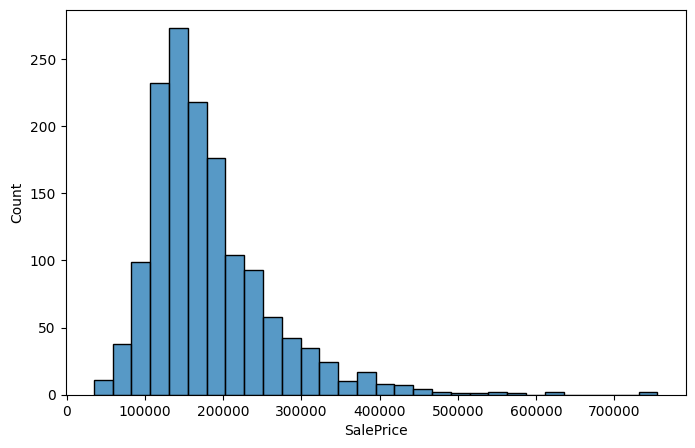

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins=30)
plt.show()

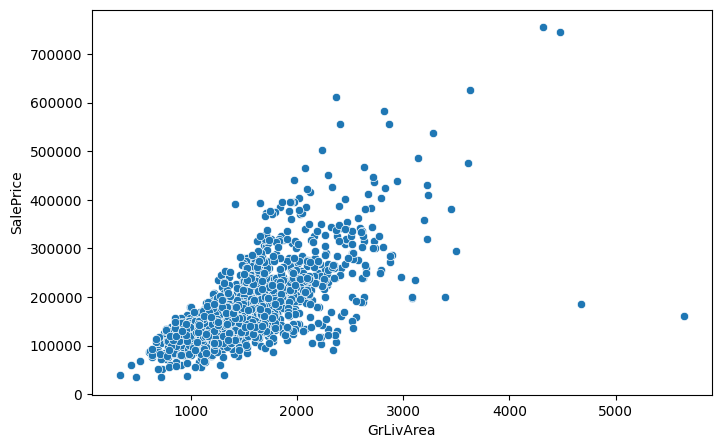

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='GrLivArea',
    y='SalePrice',
    data=df
)
plt.show()

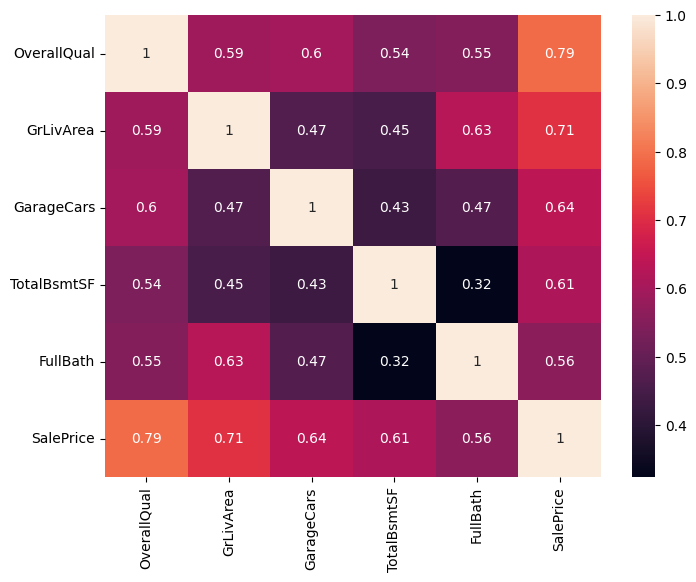

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [23]:
X = df.drop('SalePrice', axis=1)

y = df['SalePrice']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [26]:
predictions = model.predict(X_test)
predictions[:10]

array([143056.35725216, 288157.71206268, 135652.28758269, 187642.48152633,
       293548.62481568,  45878.70317157, 215698.5807844 , 174656.98651606,
        45878.70317157, 126140.67446858])

In [27]:
mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 25453.16403030073
R² Score: 0.7908695315439264


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    r2_score(
        y_test,
        rf_pred
    )
)

0.886711033451767


In [30]:
import pickle

pickle.dump(
    rf,
    open(
        'house_price_model.pkl',
        'wb'
    )
)

In [31]:
files.download(
    'house_price_model.pkl'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>